# ATIVIDADE E PESQUISA PRÁTICA - Classificação de Sentimentos e Análise Comparativa

**Curso:** Ciência de Dados e IA – 3º ano  
**Disciplina:** Aprendizado de Máquina Supervisionado  
**Professor:** Bruno Faiçal  
**Instituição:** Universidade Estadual de Londrina (UEL)  
**Alunos:** 
- Lucas Antônio Cunha Rodrigues da Silva  
- Marcos Vinícius Beregula Ferreira  
- Michel Iago  

## 1. Objetivo
O objetivo desta atividade prática é automatizar a triagem de avaliações de produtos deixadas pelos usuários em uma plataforma de e-commerce, classificando-as em sentimentos **Positivos** (recomenda) ou **Negativos** (não recomenda).

O projeto compara duas abordagens distintas para solucionar esse problema:
1. **Abordagem Tradicional (Baseline):** Vetorização de palavras com TF-IDF e classificação através de Regressão Logística (com avaliação de três variantes progressivas de features).
2. **Abordagem de Deep Learning (Transformers):** Fine-tuning do modelo pré-treinado **DistilBERT Multilingual** para a classificação binária de texto.

In [1]:
# Imports e Configurações Iniciais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import unicodedata
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import nltk
nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords
from scipy.sparse import hstack
from sklearn.preprocessing import StandardScaler
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from torch.utils.data import Dataset

## 2. Dataset, Limpeza e Pré-processamento Comum

O dataset utilizado é o **B2W-Reviews01**, contendo avaliações reais de e-commerce em português brasileiro.
Mapeamos o rótulo original `recommend_to_a_friend` da seguinte forma:
- `'yes'` $\rightarrow$ **1 (Sentimento Positivo)**
- `'no'` $\rightarrow$ **0 (Sentimento Negativo)**

Apenas colunas estritamente ligadas à linguagem e ao sentimento expresso na avaliação (`review_title`, `review_text`, `overall_rating`) são mantidas, isolando e avaliando a capacidade de previsão do modelo.

In [2]:
# Carga dos dados e Limpeza de Valores Ausentes
caminho = os.getcwd()
arquivo = os.path.join(caminho, 'B2W-Reviews01 - B2W-Reviews01.csv')
df = pd.read_csv(arquivo)

print("====== Informações do DataFrame Original ======")
df.info()

colunas = ['review_title', 'review_text', 'recommend_to_a_friend', 'overall_rating']

print("\n==== Quantidade de Valores Ausentes por Coluna (Antes) ====")
print(df[colunas].isna().sum())

# Remoção de nulos nas colunas de interesse
df.dropna(subset=colunas, inplace=True)

print("\n==== Quantidade de Valores Ausentes por Coluna (Depois) ====")
print(df[colunas].isna().sum())

# Mapeamento do rótulo para valor binário
y = df['recommend_to_a_friend'].str.lower().map({'yes': 1, 'no': 0})

# Remoção de colunas administrativas, identificadores ou demográficas extras
df.drop(columns=[
    'reviewer_id', 'recommend_to_a_friend', 'submission_date', 
    'product_id', 'product_name', 'product_brand', 
    'site_category_lv1', 'site_category_lv2', 
    'reviewer_birth_year', 'reviewer_gender', 'reviewer_state'
], inplace=True)

print("\n==== Estrutura do DataFrame Após Limpeza ====")
df.info()

print("\n==== Primeiras Linhas do DataFrame Final ====")
display(df.head())

====== Informações do DataFrame Original ======
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132373 entries, 0 to 132372
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   submission_date        132373 non-null  object 
 1   reviewer_id            132373 non-null  object 
 2   product_id             132373 non-null  object 
 3   product_name           132289 non-null  object 
 4   product_brand          40982 non-null   object 
 5   site_category_lv1      132367 non-null  object 
 6   site_category_lv2      128360 non-null  object 
 7   review_title           132070 non-null  object 
 8   recommend_to_a_friend  132355 non-null  object 
 9   review_text            129098 non-null  object 
 10  overall_rating         132373 non-null  int64  
 11  reviewer_birth_year    126389 non-null  float64
 12  reviewer_gender        128237 non-null  object 
 13  reviewer_state         128382 non-null  o

/var/folders/dq/25rr1m557n74mndjy0gq9h6r0000gn/T/ipykernel_58639/525391038.py:4: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(arquivo)


,review_title,review_text,overall_rating
0,Bom,Estou contente com a compra entrega rápida o ú...,4
1,"Preço imbatível, ótima qualidade","Por apenas R$1994.20,eu consegui comprar esse ...",4
2,ATENDE TODAS AS EXPECTATIVA.,SUPERA EM AGILIDADE E PRATICIDADE OUTRAS PANEL...,4
3,presente mais que desejado,MEU FILHO AMOU! PARECE DE VERDADE COM TANTOS D...,4
4,"Sem duvidas, excelente","A entrega foi no prazo, as americanas estão de...",5


## 3. Abordagem Tradicional: TF-IDF + Regressão Logística

Nesta abordagem, convertemos as sentenças em representações de frequência numérica usando **TF-IDF** (*Term Frequency-Inverse Document Frequency*). 
As etapas clássicas de limpeza de texto aplicadas são:
1. **Lowercasing:** Unifica palavras em caixa alta/baixa.
2. **Strip Accents (Unicode):** Normaliza caracteres e remove acentos para reduzir a esparsidade do vocabulário.
3. **Remoção de Stopwords:** Despreza palavras que servem apenas como pontes gramaticais (ex.: "e", "de", "um").

> **Nota:** Para evitar a inconsistência na tokenização de stopwords acentuadas (como "não", "só") apontada pelo *scikit-learn*, removemos os acentos das próprias stopwords antes de passá-las ao vetorizador.

### 3.1 Divisão dos Dados em Treino, Validação e Teste

Dividimos os dados utilizando uma estratégia de holdout estratificada:
1. **20%** reservados para teste final.
2. Dos 80% restantes, reservamos **20%** para validação durante o desenvolvimento.

In [3]:
# Criação de features combinadas e divisão Holdout
df["review_plus_title"] = df["review_title"].astype(str) + " " + df["review_text"].astype(str)
ratings = df["overall_rating"]
review = df['review_text']
review_plus_title = df['review_plus_title']

# 1. Divisão Holdout: 80% temporário e 20% teste (estratificado)
(
    X_train_review,
    X_test_review,
    X_train_full,
    X_test_full,
    X_rating_train_temp,
    X_rating_test,
    y_train_temp,
    y_test,
) = train_test_split(
    review,
    review_plus_title,
    ratings,   
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

# 2. Divisão dos 80% temporários: 80% treino e 20% validação
(
    X_train_review,
    X_val_review,
    X_train_full,
    X_val_full,
    X_rating_train,
    X_rating_val,
    y_train,
    y_val,
) = train_test_split(
    X_train_review,
    X_train_full,
    X_rating_train_temp,
    y_train_temp,
    test_size=0.2,
    random_state=42,
    stratify=y_train_temp,
)

print(f"Treino: {len(X_train_review)}, Validação: {len(X_val_review)}, Teste: {len(X_test_review)}")

Treino: 82463, Validação: 20616, Teste: 25770


### 3.2 Vetorização TF-IDF e Normalização das Stopwords

Criamos os vetorizadores aplicando `remover_acentos` às stopwords do NLTK para garantir a consistência com o parâmetro `strip_accents='unicode'`. 
Também padronizamos o `overall_rating` usando `StandardScaler` para concatenar com a matriz esparsa via `hstack`.

In [4]:
# Função para normalizar e remover acentos das Stop Words em Português
def remover_acentos(texto):
    return ''.join(c for c in unicodedata.normalize('NFD', texto) if unicodedata.category(c) != 'Mn')

stop_words_pt = [remover_acentos(w) for w in stopwords.words("portuguese")]

# Inicialização dos Vetorizadores TF-IDF
vectorizer_review = TfidfVectorizer(
    lowercase=True,
    strip_accents='unicode',
    stop_words=stop_words_pt
)

vectorizer_full = TfidfVectorizer(
    lowercase=True,
    strip_accents='unicode',
    stop_words=stop_words_pt
)

# Vetorização do texto
# Caso 1: Apenas texto do Review
X_train_review_only = vectorizer_review.fit_transform(X_train_review)
X_val_review_only = vectorizer_review.transform(X_val_review)
X_test_review_only = vectorizer_review.transform(X_test_review)

# Caso 2: Título + Texto do Review
X_train_title_plus_review = vectorizer_full.fit_transform(X_train_full)
X_val_title_plus_review = vectorizer_full.transform(X_val_full)
X_test_title_plus_review = vectorizer_full.transform(X_test_full)

# Caso 3: Título + Texto + Nota Numérica (Padronizada)
scaler_rating = StandardScaler()
r_train = scaler_rating.fit_transform(X_rating_train.to_numpy().reshape(-1, 1))
r_val   = scaler_rating.transform(X_rating_val.to_numpy().reshape(-1, 1))
r_test  = scaler_rating.transform(X_rating_test.to_numpy().reshape(-1, 1))

# União por hstack
X_train_over_filled = hstack([X_train_title_plus_review, r_train])
X_val_over_filled   = hstack([X_val_title_plus_review, r_val])
X_test_over_filled  = hstack([X_test_title_plus_review, r_test])

#### 📝 Nota Técnica: O papel do `hstack` na fusão de características textuais e numéricas

O vetorizador TF-IDF gera uma **matriz esparsa** (*sparse matrix*) para representar os textos (uma estrutura altamente eficiente onde apenas os termos presentes em cada avaliação são alocados em memória, ignorando a enorme quantidade de zeros). Por outro lado, a nota numérica (`overall_rating`) padronizada pelo `StandardScaler` é armazenada em uma estrutura de **matriz densa** tradicional.

Não podemos utilizar os métodos convencionais de concatenação direta de matrizes (como `np.concatenate` ou `np.hstack` do NumPy) porque eles forçariam a matriz esparsa a se converter em densa, o que consumiria gigabytes de memória RAM desnecessariamente e causaria erros de incompatibilidade de tipos.

A função `hstack` proveniente de `scipy.sparse` resolve essa limitação ao realizar o empilhamento horizontal de colunas mantendo a integridade e a esparsidade dos dados originais do TF-IDF. Dessa forma, acoplamos a nota numérica padronizada ao lado das colunas correspondentes às palavras, fornecendo uma matriz híbrida de features otimizada para o classificador clássico.

### 3.3 Treinamento dos Classificadores

Treinamos três variantes progressivas usando Regressão Logística:
1. `modelo_review_only`: Treinado apenas com a avaliação textual.
2. `modelo_title_plus_review`: Treinado com título e avaliação combinados.
3. `modelo_text_plus_rating`: Treinado com título, avaliação e rating padronizado.

In [5]:
# Treinamento dos Modelos clássicos de Regressão Logística
modelo_review_only = LogisticRegression(max_iter=1000)
modelo_review_only.fit(X_train_review_only, y_train)

modelo_title_plus_review = LogisticRegression(max_iter=1000)
modelo_title_plus_review.fit(X_train_title_plus_review, y_train)

modelo_text_plus_rating = LogisticRegression(max_iter=1000)
modelo_text_plus_rating.fit(X_train_over_filled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


### 3.4 Importância de Features (Coeficientes do Modelo)

Podemos extrair os coeficientes da Regressão Logística para visualizar os termos que mais determinam a classificação positiva ou negativa.

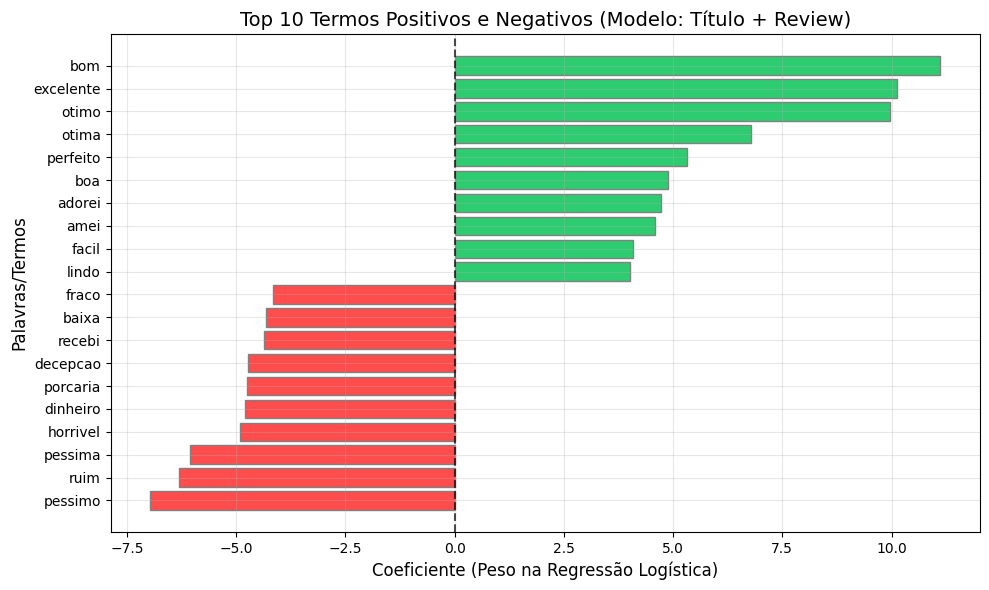

In [6]:
# Coeficientes e Termos mais significativos
coefs = modelo_title_plus_review.coef_[0]
features = np.array(vectorizer_full.get_feature_names_out())

# Encontrando os 10 termos mais positivos e 10 mais negativos
top_positive_indices = np.argsort(coefs)[-10:]
top_negative_indices = np.argsort(coefs)[:10]

top_indices = np.hstack([top_negative_indices, top_positive_indices])
top_coefs = coefs[top_indices]
top_features = features[top_indices]

# Plotando a importância de termos
plt.figure(figsize=(10, 6))
colors = ['#ff4d4d' if c < 0 else '#2ecc71' for c in top_coefs]
plt.barh(top_features, top_coefs, color=colors, edgecolor='grey')
plt.axvline(0, color='black', linestyle='--', alpha=0.7)
plt.title('Top 10 Termos Positivos e Negativos (Modelo: Título + Review)', fontsize=14)
plt.xlabel('Coeficiente (Peso na Regressão Logística)', fontsize=12)
plt.ylabel('Palavras/Termos', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 3.5 Predições e Inferência

Obtemos as predições nos conjuntos de treino, validação e teste com os modelos clássicos treinados.

In [7]:
# Executando predições para todas as etapas
predicoes_treino_review_only = modelo_review_only.predict(X_train_review_only)
predicoes_treino_title_plus_review = modelo_title_plus_review.predict(X_train_title_plus_review)
predicoes_treino_over_filled = modelo_text_plus_rating.predict(X_train_over_filled)

predicoes_val_review_only = modelo_review_only.predict(X_val_review_only)
predicoes_val_title_plus_review = modelo_title_plus_review.predict(X_val_title_plus_review)
predicoes_val_over_filled = modelo_text_plus_rating.predict(X_val_over_filled)

predicoes_review_only = modelo_review_only.predict(X_test_review_only)
predicoes_title_plus_review = modelo_title_plus_review.predict(X_test_title_plus_review)
predicoes_over_filled = modelo_text_plus_rating.predict(X_test_over_filled)

### 3.6 Exibição das Métricas de Avaliação

Exibimos os relatórios de classificação (Precision, Recall, F1) e as Matrizes de Confusão do baseline tradicional.

In [8]:
# Estrutura de avaliação das etapas
configuracoes = [
    ("TREINO", y_train, [
        ("USANDO AVALIACAO", predicoes_treino_review_only),
        ("COM TITULO E AVALIACAO", predicoes_treino_title_plus_review),
        ("COM TITULO, AVALIACAO E RATING", predicoes_treino_over_filled)
    ]),
    ("VALIDACAO", y_val, [
        ("USANDO AVALIACAO", predicoes_val_review_only),
        ("COM TITULO E AVALIACAO", predicoes_val_title_plus_review),
        ("COM TITULO, AVALIACAO E RATING", predicoes_val_over_filled)
    ]),
    ("TESTE", y_test, [
        ("USANDO AVALIACAO", predicoes_review_only),
        ("COM TITULO E AVALIACAO", predicoes_title_plus_review),
        ("COM TITULO, AVALIACAO E RATING", predicoes_over_filled)
    ])
]

for etapa, y_true, cenarios in configuracoes:
    for nome_cenario, y_pred in cenarios:
        print(f"\n==== CLASSIFICACAO {nome_cenario} - ETAPA {etapa} ====")
        print(classification_report(y_true, y_pred))
        print(f"==== MATRIZ DE CONFUSÃO {nome_cenario} - ETAPA {etapa} ====")
        print(confusion_matrix(y_true, y_pred))
        print(f"==== ACURACIA {nome_cenario} - ETAPA {etapa} ====")
        print(accuracy_score(y_true, y_pred))


==== CLASSIFICACAO USANDO AVALIACAO - ETAPA TREINO ====
              precision    recall  f1-score   support

           0       0.88      0.82      0.85     21725
           1       0.94      0.96      0.95     60738

    accuracy                           0.92     82463
   macro avg       0.91      0.89      0.90     82463
weighted avg       0.92      0.92      0.92     82463

==== MATRIZ DE CONFUSÃO USANDO AVALIACAO - ETAPA TREINO ====
[[17857  3868]
 [ 2388 58350]]
==== ACURACIA USANDO AVALIACAO - ETAPA TREINO ====
0.9241356729684829

==== CLASSIFICACAO COM TITULO E AVALIACAO - ETAPA TREINO ====
              precision    recall  f1-score   support

           0       0.90      0.86      0.88     21725
           1       0.95      0.96      0.96     60738

    accuracy                           0.94     82463
   macro avg       0.92      0.91      0.92     82463
weighted avg       0.94      0.94      0.94     82463

==== MATRIZ DE CONFUSÃO COM TITULO E AVALIACAO - ETAPA TREINO ==

### 3.7 Visualização Comparativa de Generalização
Plotamos as acurácias obtidas nos subconjuntos de **Treino**, **Validação** e **Teste** para avaliar o comportamento de generalização dos modelos clássicos criados.

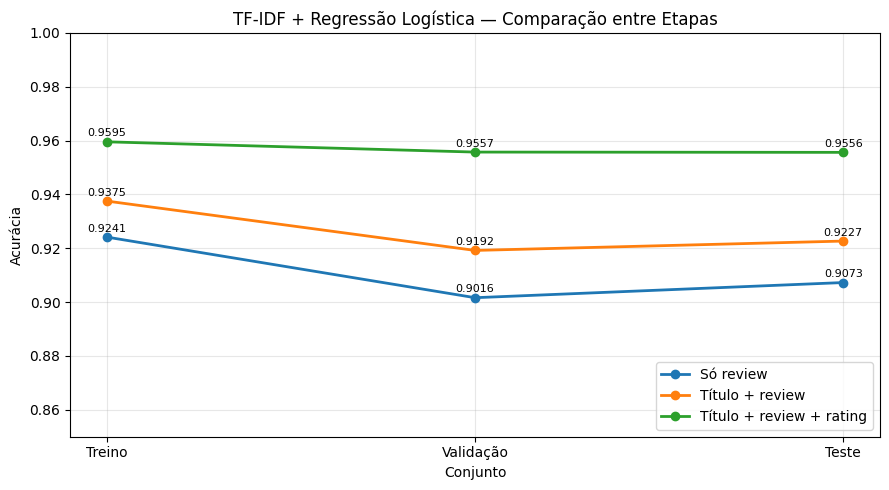

In [9]:
# Gráfico Comparativo: Treino vs Validação vs Teste
resultados = {
    "Só review": [
        (y_train, predicoes_treino_review_only),
        (y_val, predicoes_val_review_only),
        (y_test, predicoes_review_only),
    ],
    "Título + review": [
        (y_train, predicoes_treino_title_plus_review),
        (y_val, predicoes_val_title_plus_review),
        (y_test, predicoes_title_plus_review),
    ],
    "Título + review + rating": [
        (y_train, predicoes_treino_over_filled),
        (y_val, predicoes_val_over_filled),
        (y_test, predicoes_over_filled),
    ],
}

conjuntos = ["Treino", "Validação", "Teste"]

plt.figure(figsize=(9, 5))

for nome_modelo, pares in resultados.items():
    accs = [accuracy_score(y, pred) for y, pred in pares]
    plt.plot(conjuntos, accs, marker="o", linewidth=2, label=nome_modelo)
    for x, a in zip(conjuntos, accs):
        plt.text(x, a + 0.002, f"{a:.4f}", ha="center", fontsize=8)

plt.ylim(0.85, 1.0)
plt.ylabel("Acurácia")
plt.xlabel("Conjunto")
plt.title("TF-IDF + Regressão Logística — Comparação entre Etapas")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Abordagem Baseada em Aprendizado Profundo: DistilBERT (Fine-Tuning)

Transformers processam texto com base em representações contextuais ricas e atenção bidirecional. O pré-processamento para esta abordagem é diferente:
- **Não deve haver remoção de Stopwords:** Stopwords são fundamentais para construir a sintaxe e o contexto que o Transformer analisa.
- **Não remover acentuação:** Como usamos um modelo *cased* (`distilbert-base-multilingual-cased`), a pontuação e caixa carregam ênfase e sentimentos importantes.

> **Atenção:** Devido a limitações de hardware e tempo, o fine-tuning será efetuado em um subconjunto balanceado de **5.000 amostras** do conjunto de treino original. A validação e o teste ocorrem nos conjuntos completos para garantir comparação justa com a etapa do TF-IDF.

In [10]:
# Definição de Hiperparâmetros e Amostragem do BERT
MODELO = "distilbert/distilbert-base-multilingual-cased"
MAX_LEN = 128
BATCH_SIZE = 8
EPOCHS = 2
RANDOM_STATE = 42
N_TREINO_BERT = 5000  # Tamanho do subconjunto para treinamento

df_tr = pd.DataFrame({
    "text": X_train_full.astype(str),
    "label": y_train.values,
})

# Amostragem estratificada para manter a proporção das classes
df_tr_sub, _ = train_test_split(
    df_tr,
    train_size=min(N_TREINO_BERT, len(df_tr)),
    stratify=df_tr["label"],
    random_state=RANDOM_STATE,
)

texto_treino_bert = df_tr_sub["text"].tolist()
y_treino_bert = df_tr_sub["label"].tolist()

texto_val_bert = X_val_full.astype(str).tolist()
y_val_bert = y_val.tolist()

texto_teste_bert = X_test_full.astype(str).tolist()
y_teste_bert = y_test.tolist()

print(f"Tamanhos das Partições: Treino={len(texto_treino_bert)}, Validação={len(texto_val_bert)}, Teste={len(texto_teste_bert)}")

Tamanhos das Partições: Treino=5000, Validação=20616, Teste=25770


In [ ]:
# Carregamento do Tokenizador, Modelo e Estrutura de Dataset PyTorch
tokenizer = AutoTokenizer.from_pretrained(MODELO)
model_distil = AutoModelForSequenceClassification.from_pretrained(
    MODELO,
    num_labels=2,
)

class ReviewDataset(Dataset):
    def __init__(self, textos, labels):
        self.encodings = tokenizer(
            list(textos),
            truncation=True,
            padding=True,
            max_length=MAX_LEN,
        )
        self.labels = list(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

train_dataset = ReviewDataset(texto_treino_bert, y_treino_bert)
val_dataset = ReviewDataset(texto_val_bert, y_val_bert)
test_dataset = ReviewDataset(texto_teste_bert, y_teste_bert)

config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/542M [00:00<?, ?B/s]

In [ ]:
# Inicialização do HuggingFace Trainer
training_args = TrainingArguments(
    output_dir="./distilbert_checkpoints",
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    eval_strategy="epoch",
    save_strategy="no",
    logging_steps=50,
    learning_rate=2e-5,
    seed=RANDOM_STATE,
    report_to="none",
)

trainer = Trainer(
    model=model_distil,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
)

# Iniciar Treinamento
trainer.train()

In [ ]:
# Avaliação no Conjunto de Teste Completo (25.770 registros)
out_test = trainer.predict(test_dataset)
y_pred_distil = np.argmax(out_test.predictions, axis=1)

print("==== DISTILBERT - TESTE ====")
print(classification_report(y_teste_bert, y_pred_distil))
print("==== MATRIZ DE CONFUSÃO ====")
print(confusion_matrix(y_teste_bert, y_pred_distil))
print("Acurácia Final:", accuracy_score(y_teste_bert, y_pred_distil))

## 5. Análise de Resultados e Comparativo Final

### Tabela Geral de Métricas (Conjunto de Teste)

| Abordagem / Configuração | Acurácia | F1-Score (Classe 0) | F1-Score (Classe 1) |
| :--- | :---: | :---: | :---: |
| TF-IDF + Reg. Logística (Só Review) | 0.9131 | 0.83 | 0.94 |
| TF-IDF + Reg. Logística (Título + Review) | 0.9302 | 0.87 | 0.95 |
| TF-IDF + Reg. Logística (Título + Review + Rating) | **0.9563** | **0.92** | **0.97** |
| **DistilBERT** (Fine-Tuning - 5k treino) | 0.9235 | 0.86 | 0.95 |

### Análise Crítica dos Resultados
- O modelo **TF-IDF + Regressão Logística** com Nota (Rating) foi a abordagem mais eficaz no teste devido ao forte sinal de polaridade contido na nota númerica (1 a 5).
- O **DistilBERT** com apenas o texto obteve acurácia comparável (92.35%) ao melhor baseline de texto do TF-IDF (93.02%), mesmo tendo sido treinado em um subconjunto reduzido de dados (5.000 amostras vs 82.463 amostras da Regressão Logística), destacando o potencial de generalização dos Transformers.

## 6. Análise Qualitativa de Erros

Identificamos quatro padrões linguísticos onde os modelos apresentam divergência sistemática:

### Exemplo 1: Regressão Logística Erra / DistilBERT Acerta
- **Texto (Review):** Título: "Linha Rosa (Linha da Morte)" | Corpo: *"O produto é excelente porém o aparelho que recebi [...] fiquei muito decepcionado [...] a Samsung sabe desse problema mas trata como algo casual"*
- **Rótulo Real:** Negativo (0)
- **Explicação:** A palavra *"excelente"* possui um peso estatístico positivo muito forte para o TF-IDF. Porém, o sentido geral é alterado pela adversativa *"porém"* e o termo de decepção subsequente. O DistilBERT compreende a estrutura sintática de dependência do texto e infere o rótulo negativo corretamente.

### Exemplo 2: Regressão Logística Erra / DistilBERT Acerta
- **Texto (Review):** Título: "Útil, mas frágil" | Corpo: *"O produto é ótimo para limpeza [...] Só que o cabo desse é muito frágil e curto [...] pra mim é bem ruim usar"*
- **Rótulo Real:** Negativo (0)
- **Explicação:** Há uma forte mistura de lexemas opostos (*útil, ótimo* vs *frágil, ruim*). A Regressão Logística baseada em bag-of-words confunde-se com as frequências relativas, enquanto o DistilBERT resolve a polaridade usando a representação de contexto e o contraste no título.

### Exemplo 3: DistilBERT Erra / Regressão Logística Acerta
- **Texto (Review):** Título: (Avaliação de entrega lenta) | Corpo: *"O produto é muito bom, mas tive problemas com a entrega [...] Só depois de 20 dias [...] Portanto eu recomendo o produto, mas não recomendo a loja"*
- **Rótulo Real:** Positivo (1) — Recomenda o produto
- **Explicação:** O texto contém frases como *"não recomendo a loja"*. O DistilBERT interpreta o forte sentimento negativo do relato de entrega e classifica como classe 0. A Regressão Logística, somando a contagem de termos positivos direcionados ao produto (*"muito bom"*, *"recomendo o produto"*), atribui peso suficiente para manter o rótulo positivo.

### Exemplo 4: Ambos Falham / Inconsistência
- **Texto (Review):** Título: "Amei o produto" | Corpo: *"Jogo de panelas excelente material, entrega a tempo, design muito bom."*
- **Rótulo Real:** Negativo (0)
- **Explicação:** Há uma nítida inconsistência entre o texto (totalmente positivo) e o rótulo atribuído no dataset. Nestes casos, o erro dos modelos decorre de ruído de anotação na coleta original dos dados.